# CS 281 Final Experiments — Is Chain-of-Thought Just Rationalization?

## 1. Setup

In [1]:
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run(['pip', 'install', '-q',
                    'transformer-lens>=2.0', 'datasets>=2.18',
                    'huggingface-hub>=0.22', 'accelerate>=0.28', 'seaborn'], check=True)

In [2]:
import os, sys
if 'google.colab' in sys.modules:
    from google.colab import userdata
    os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
else:
    from dotenv import load_dotenv
    load_dotenv()
assert os.environ.get('HF_TOKEN'), 'HF_TOKEN not set. Local: .env. Colab: Secret named HF_TOKEN.'
print('HF_TOKEN loaded:', os.environ['HF_TOKEN'][:6] + '...')

HF_TOKEN loaded: hf_Khd...


In [3]:
import os, sys
if 'google.colab' in sys.modules:
    if not os.path.isdir('cot-faithfulness-audit'):
        subprocess.run(['git', 'clone', 'https://github.com/bballhaus/cot-faithfulness-audit.git'], check=True)
    os.chdir('/content/cot-faithfulness-audit')
sys.path.insert(0, os.path.abspath('.'))
print('cwd:', os.getcwd(), '| package present:', os.path.isdir('cot_faithfulness'))

cwd: /content/cot-faithfulness-audit | package present: True


In [4]:
import json, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from cot_faithfulness import (data, model as model_mod, prompts, generation,
                              logit_lens, tuned_lens, patching, analysis, experiments)

RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)
torch.set_grad_enabled(False)
sns.set_context('notebook'); sns.set_style('whitegrid')

## 2. Config

In [5]:
CFG = dict(
    model_name = model_mod.DEFAULT_MODEL,
    N_BOOLQ    = 1500,
    N_MNLI     = 1000,
    TAU        = 0.8,
    TAUS       = (0.5, 0.7, 0.8, 0.9),
    MAX_LEN    = 1024,
    COT_TOKENS = 180,
    TUNED_FIT_N = 96,
    TUNED_EVAL_N = 250,
    QUAL_K     = 25,
    SEED       = 42,
)
print(json.dumps(CFG, indent=2, default=str))

{
  "model_name": "meta-llama/Meta-Llama-3-8B-Instruct",
  "N_BOOLQ": 1500,
  "N_MNLI": 1000,
  "TAU": 0.8,
  "TAUS": [
    0.5,
    0.7,
    0.8,
    0.9
  ],
  "MAX_LEN": 1024,
  "COT_TOKENS": 180,
  "TUNED_FIT_N": 96,
  "TUNED_EVAL_N": 250,
  "QUAL_K": 25,
  "SEED": 42
}


## 3. Load model

In [6]:
model = model_mod.load_model(name=CFG['model_name'])
device = next(model.parameters()).device
N_LAYERS = model.cfg.n_layers
print(f'Loaded {model.cfg.model_name} on {device} | n_layers={N_LAYERS} | d_vocab={model.cfg.d_vocab}')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Meta-Llama-3-8B-Instruct into HookedTransformer
Loaded Meta-Llama-3-8B-Instruct on cuda:0 | n_layers=32 | d_vocab=128256


## 4. Load data

In [7]:
boolq = data.load_boolq(n=CFG['N_BOOLQ'], seed=CFG['SEED'])
mnli  = data.load_mnli(n=CFG['N_MNLI'], seed=CFG['SEED'])
print('BoolQ:', len(boolq), '| MNLI:', len(mnli))

BoolQ: 1500 | MNLI: 1000


## 5. Commitment: no-CoT baseline vs with-CoT (BoolQ)

In [8]:
recs_nocot, probs_nocot = experiments.run_commitment(
    model, boolq, 'boolq', tau=CFG['TAU'], with_cot=False, max_len=CFG['MAX_LEN'])
pd.DataFrame(recs_nocot).to_csv(RESULTS / 'boolq_commitment_nocot.csv', index=False)
np.save(RESULTS / 'boolq_probs_nocot.npy', probs_nocot)
len(recs_nocot)

commitment boolq cot=False:   0%|          | 0/1500 [00:00<?, ?it/s]

1500

In [9]:
recs_cot, probs_cot = experiments.run_commitment(
    model, boolq, 'boolq', tau=CFG['TAU'], with_cot=True,
    max_len=CFG['MAX_LEN'], max_new_tokens=CFG['COT_TOKENS'])
pd.DataFrame(recs_cot).to_csv(RESULTS / 'boolq_commitment_cot.csv', index=False)
np.save(RESULTS / 'boolq_probs_cot.npy', probs_cot)
len(recs_cot)

commitment boolq cot=True:   0%|          | 0/1500 [00:00<?, ?it/s]

1500

In [10]:
summ_nocot = analysis.commitment_summary_ci(recs_nocot)
summ_cot   = analysis.commitment_summary_ci(recs_cot)
print('NO-COT  :', json.dumps(summ_nocot, indent=2, default=float))
print('WITH-COT:', json.dumps(summ_cot, indent=2, default=float))

NO-COT  : {
  "n": 1500,
  "mean_commitment_layer": 29.4215283483977,
  "median_commitment_layer": 30.0,
  "frac_committed": 0.8113333333333334,
  "accuracy": 0.8473333333333334,
  "mean_layer_correct=False": 30.0,
  "mean_layer_correct=True": 29.42057613168724,
  "mean_commitment_layer_ci": {
    "point": 29.4215283483977,
    "lo": 29.359901396877568,
    "hi": 29.482333607230895,
    "n": 1217
  },
  "frac_committed_ci": {
    "point": 0.8113333333333334,
    "lo": 0.7913333333333333,
    "hi": 0.8306666666666667,
    "n": 1500
  },
  "accuracy_ci": {
    "point": 0.8473333333333334,
    "lo": 0.8286666666666667,
    "hi": 0.8646666666666667,
    "n": 1500
  }
}
WITH-COT: {
  "n": 1500,
  "mean_commitment_layer": 29.968241042345277,
  "median_commitment_layer": 30.0,
  "frac_committed": 0.8186666666666667,
  "accuracy": 0.838,
  "mean_layer_correct=False": NaN,
  "mean_layer_correct=True": 29.968241042345277,
  "mean_commitment_layer_ci": {
    "point": 29.968241042345277,
    "lo":

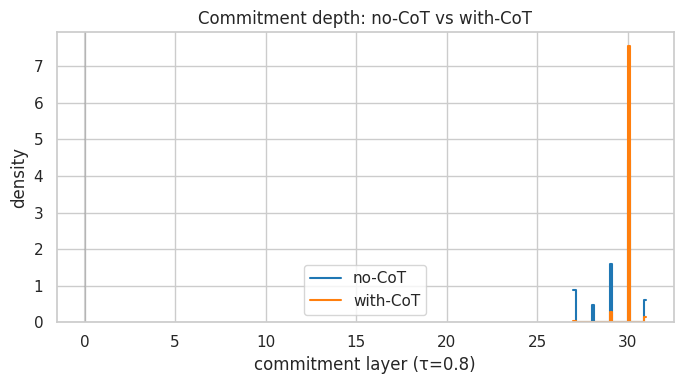

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
analysis.plot_commitment_compare(recs_nocot, recs_cot, N_LAYERS, ax=ax)
plt.tight_layout(); plt.savefig(RESULTS / 'commitment_compare.png', dpi=150); plt.show()

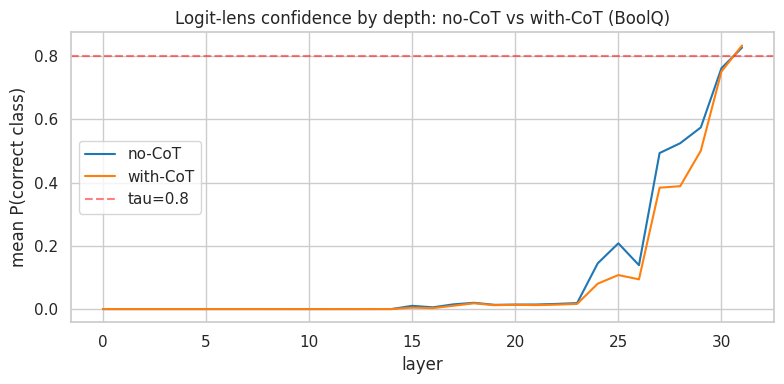

In [12]:
def mean_pcorrect(probs, recs):
    labels = np.array([r['label'] for r in recs])
    return probs[np.arange(len(recs)), :, labels].mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mean_pcorrect(probs_nocot, recs_nocot), label='no-CoT')
ax.plot(mean_pcorrect(probs_cot, recs_cot), label='with-CoT')
ax.axhline(CFG['TAU'], color='red', ls='--', alpha=0.5, label=f"tau={CFG['TAU']}")
ax.set_xlabel('layer'); ax.set_ylabel('mean P(correct class)')
ax.set_title('Logit-lens confidence by depth: no-CoT vs with-CoT (BoolQ)')
ax.legend(); plt.tight_layout(); plt.savefig(RESULTS / 'mean_curve_compare.png', dpi=150); plt.show()

## 6. Threshold sensitivity (tau sweep)

In [13]:
labels_nocot = np.array([r['label'] for r in recs_nocot])
labels_cot   = np.array([r['label'] for r in recs_cot])
sweep_nocot = analysis.threshold_sweep(probs_nocot, labels_nocot, taus=CFG['TAUS'])
sweep_cot   = analysis.threshold_sweep(probs_cot,   labels_cot,   taus=CFG['TAUS'])
sweep_nocot['prompt'] = 'no-CoT'; sweep_cot['prompt'] = 'with-CoT'
sweep = pd.concat([sweep_nocot, sweep_cot], ignore_index=True)
sweep.to_csv(RESULTS / 'threshold_sweep.csv', index=False)
sweep

,tau,frac_committed,mean_layer,median_layer,mean_depth_frac,prompt
0,0.5,0.854667,27.832293,27.0,0.897816,no-CoT
1,0.7,0.828667,28.902655,30.0,0.932344,no-CoT
2,0.8,0.811333,29.421528,30.0,0.949082,no-CoT
3,0.9,0.768000,30.193576,30.0,0.973986,no-CoT
4,0.5,0.838667,28.606518,29.0,0.922791,with-CoT
5,0.7,0.824000,29.726537,30.0,0.958921,with-CoT
6,0.8,0.818667,29.968241,30.0,0.966717,with-CoT
7,0.9,0.807333,30.576383,31.0,0.986335,with-CoT


## 7. Qualitative extremes (with-CoT commitment)

In [14]:
qual = analysis.qualitative_extremes(recs_cot, k=CFG['QUAL_K'], text_key='cot_text')
qual.to_csv(RESULTS / 'qualitative_extremes.csv', index=False)
print('early-commit example:\n', qual[qual.group=='early'].iloc[0]['cot_text'][:400])
print('\nlate-commit example:\n', qual[qual.group=='late'].iloc[0]['cot_text'][:400])
qual[['idx','commitment_layer','correct','group']]

early-commit example:
 The passage states that the UK government invoked Article 50 on 29 March 2017, which started the process of leaving the EU. It also mentions that the UK is due to leave the EU on 29 March 2019. However, it does not state that the UK has actually left the EU yet.

Therefore, the answer is:

late-commit example:
 The passage mentions that the 1916 New York Giants hold the record for the longest unbeaten streak, but it doesn't say they went undefeated. It says they had a tie in-between the 14th and 15th win, which means they didn't win every game. 

The passage also mentions other teams' winning streaks, but it doesn't mention any team going undefeated.


,idx,commitment_layer,correct,group
0,1391,27,True,early
1,460,27,True,early
2,467,27,True,early
3,1015,27,True,early
4,597,27,True,early
5,249,27,True,early
6,1411,29,True,early
7,1422,29,True,early
8,1309,29,True,early
9,1311,29,True,early


## 8. Tuned-lens robustness comparison

In [16]:
!cd /content/cot-faithfulness-audit && git pull origin main
import importlib
from cot_faithfulness import tuned_lens
importlib.reload(tuned_lens)

remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1.34 KiB | 1.34 MiB/s, done.
From https://github.com/bballhaus/cot-faithfulness-audit
 * branch            main       -> FETCH_HEAD
   10ae610..59811a0  main       -> origin/main
Updating 10ae610..59811a0
Fast-forward
 cot_faithfulness/tuned_lens.py | 8 ++++++--
 1 file changed, 6 insertions(+), 2 deletions(-)


<module 'cot_faithfulness.tuned_lens' from '/content/cot-faithfulness-audit/cot_faithfulness/tuned_lens.py'>

In [17]:
rng = random.Random(CFG['SEED'])
fit_idx = rng.sample(range(len(boolq)), min(CFG['TUNED_FIT_N'], len(boolq)))
fit_seqs = []
for i in fit_idx:
    ex = data.boolq_example(boolq[i])
    toks = model.to_tokens(prompts.format_boolq_direct(ex['passage'], ex['question']))
    if toks.shape[1] <= CFG['MAX_LEN']:
        fit_seqs.append(toks)
lens = tuned_lens.fit_tuned_lens(model, fit_seqs, rank=256, steps=250, lr=1e-3)
print('fitted tuned lens on', len(fit_seqs), 'calibration prompts')

fitted tuned lens on 96 calibration prompts


In [18]:
eval_idx = [i for i in range(len(boolq)) if i not in set(fit_idx)][:CFG['TUNED_EVAL_N']]
bt = prompts.boolq_target_tokens(model); tids = [bt['No'], bt['Yes']]
ll_layers, tl_layers = [], []
for i in tqdm(eval_idx, desc='tuned vs logit'):
    ex = data.boolq_example(boolq[i])
    toks = model.to_tokens(prompts.format_boolq_direct(ex['passage'], ex['question']))
    if toks.shape[1] > CFG['MAX_LEN']:
        continue
    pos = [toks.shape[1] - 1]
    p_ll = logit_lens.logit_lens(model, toks, tids, positions=pos)[:, 0, :]
    p_tl = tuned_lens.tuned_lens_probs(model, lens, toks, tids, positions=pos)[:, 0, :]
    ll_layers.append(logit_lens.commitment_layer(p_ll, ex['label'], CFG['TAU']))
    tl_layers.append(logit_lens.commitment_layer(p_tl, ex['label'], CFG['TAU']))
lens_cmp = {
    'logit_lens_mean_commit': analysis.bootstrap_ci([x for x in ll_layers if x >= 0]),
    'tuned_lens_mean_commit': analysis.bootstrap_ci([x for x in tl_layers if x >= 0]),
    'logit_frac_committed': float(np.mean(np.array(ll_layers) >= 0)),
    'tuned_frac_committed': float(np.mean(np.array(tl_layers) >= 0)),
}
print(json.dumps(lens_cmp, indent=2, default=float))
json.dump(lens_cmp, open(RESULTS / 'tuned_vs_logit.json', 'w'), indent=2, default=float)

tuned vs logit:   0%|          | 0/250 [00:00<?, ?it/s]

{
  "logit_lens_mean_commit": {
    "point": 29.36,
    "lo": 29.2,
    "hi": 29.515,
    "n": 200
  },
  "tuned_lens_mean_commit": {
    "point": 7.390134529147982,
    "lo": 6.802690582959642,
    "hi": 8.0,
    "n": 223
  },
  "logit_frac_committed": 0.8,
  "tuned_frac_committed": 0.892
}


## 9. CoT corruption + pre-CoT patching (MNLI)

In [19]:
mnli_random = experiments.run_corruption(
    model, mnli, 'mnli', strategy='random', do_patch=True,
    max_len=CFG['MAX_LEN'], max_new_tokens=160)
pd.DataFrame(mnli_random).to_csv(RESULTS / 'mnli_corruption_random.csv', index=False)
print('random usable =', len(mnli_random))

corruption mnli random:   0%|          | 0/1000 [00:00<?, ?it/s]

random usable = 25


In [20]:
mnli_invert = experiments.run_corruption(
    model, mnli, 'mnli', strategy='invert', do_patch=True,
    max_len=CFG['MAX_LEN'], max_new_tokens=160)
pd.DataFrame(mnli_invert).to_csv(RESULTS / 'mnli_corruption_invert.csv', index=False)
print('invert usable =', len(mnli_invert))

corruption mnli invert:   0%|          | 0/1000 [00:00<?, ?it/s]

invert usable = 25


In [21]:
sum_random = analysis.patching_summary(mnli_random, with_ci=True)
sum_invert = analysis.patching_summary(mnli_invert, with_ci=True)
print('RANDOM:', json.dumps(sum_random, indent=2, default=float))
print('INVERT:', json.dumps(sum_invert, indent=2, default=float))

RANDOM: {
  "n": 25,
  "flip_rate": 0.16,
  "mean_logit_drop": 0.1996831226348877,
  "accuracy_clean": 0.48,
  "accuracy_corrupted": 0.52,
  "patch_recovery_rate": 0.84,
  "flip_rate_ci": {
    "point": 0.16,
    "lo": 0.04,
    "hi": 0.32,
    "n": 25
  },
  "mean_logit_drop_ci": {
    "point": 0.1996831226348877,
    "lo": 0.08909397029876709,
    "hi": 0.3231258482933044,
    "n": 25
  },
  "patch_recovery_rate_ci": {
    "point": 0.84,
    "lo": 0.68,
    "hi": 0.96,
    "n": 25
  }
}
INVERT: {
  "n": 25,
  "flip_rate": 0.52,
  "mean_logit_drop": 0.5390557312965393,
  "accuracy_clean": 0.48,
  "accuracy_corrupted": 0.36,
  "patch_recovery_rate": 0.48,
  "flip_rate_ci": {
    "point": 0.52,
    "lo": 0.32,
    "hi": 0.72,
    "n": 25
  },
  "mean_logit_drop_ci": {
    "point": 0.5390557312965393,
    "lo": 0.37862245547771456,
    "hi": 0.7018609161972997,
    "n": 25
  },
  "patch_recovery_rate_ci": {
    "point": 0.48,
    "lo": 0.28,
    "hi": 0.68,
    "n": 25
  }
}


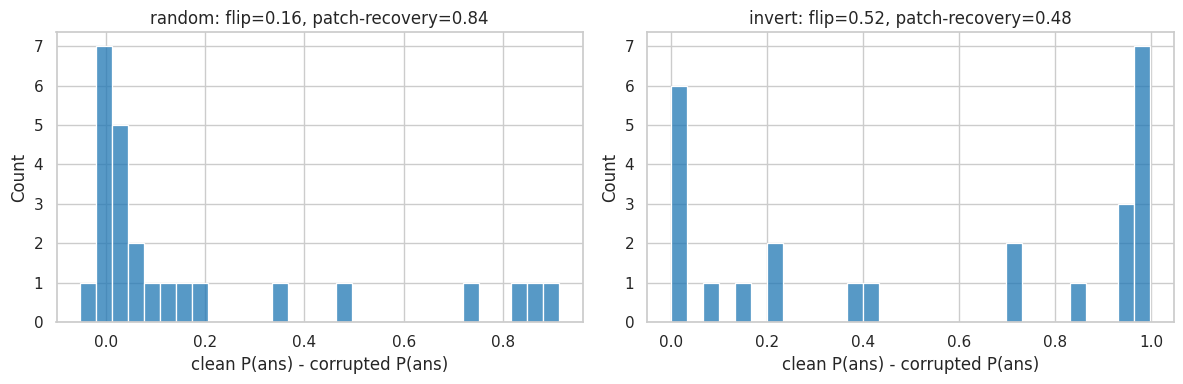

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, recs, name in [(axes[0], mnli_random, 'random'), (axes[1], mnli_invert, 'invert')]:
    df = pd.DataFrame(recs)
    sns.histplot(df['logit_diff_drop'], bins=30, ax=ax)
    fr = df['flipped'].mean()
    pr = df['patch_recovers_clean'].mean() if 'patch_recovers_clean' in df else float('nan')
    ax.set_title(f'{name}: flip={fr:.2f}, patch-recovery={pr:.2f}')
    ax.set_xlabel('clean P(ans) - corrupted P(ans)')
plt.tight_layout(); plt.savefig(RESULTS / 'mnli_corruption.png', dpi=150); plt.show()

## 10. Save final summary

In [23]:
artifact = {
    'config': {k: str(v) for k, v in CFG.items()},
    'model_name': model.cfg.model_name,
    'n_layers': N_LAYERS,
    'boolq_commitment_nocot': summ_nocot,
    'boolq_commitment_cot': summ_cot,
    'threshold_sweep': sweep.to_dict(orient='records'),
    'tuned_vs_logit': lens_cmp,
    'mnli_corruption_random': sum_random,
    'mnli_corruption_invert': sum_invert,
}
json.dump(artifact, open(RESULTS / 'final_summary.json', 'w'), indent=2, default=float)
print('Saved', RESULTS / 'final_summary.json')

Saved results/final_summary.json
